In [103]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas de scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, make_scorer

# Importar modelos
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [ ]:
data = pd.read_parquet("data.parquet")
data_new = data.iloc[:, :-23]
data_new = data_new.drop(
    columns=["track_name", "id", "artist_name", "release_date", "year"]
)



print("Dimensiones del dataset:", data_new.shape)
print(data_new.head())
print(data_new.info())
print(data_new.describe())

Dimensiones del dataset: (280453, 19)
   new_popularity_2025  acousticness  danceability  duration_ms  energy  \
0                   18      0.991000         0.598       168333   0.224   
1                    1      0.993000         0.647       163827   0.186   
2                   13      0.000173         0.730       422087   0.798   
3                    0      0.295000         0.704       165224   0.707   
4                    3      0.996000         0.424       198627   0.245   

   explicit  instrumentalness  key  liveness  loudness  mode  popularity_2021  \
0         0          0.000522    5     0.379   -12.628     0               12   
1         0          0.000018    0     0.519   -12.098     1                4   
2         0          0.801000    2     0.128    -7.311     1               17   
3         1          0.000246   10     0.402    -6.036     0                2   
4         0          0.799000    5     0.235   -11.470     1                9   

   speechiness    tempo 

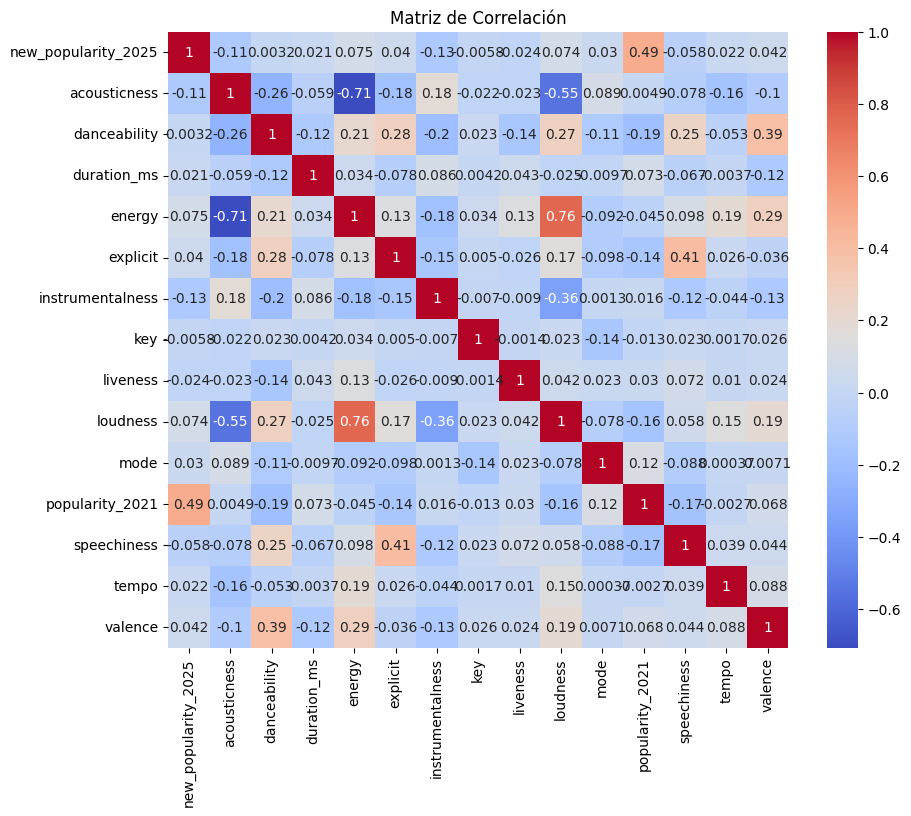

In [109]:
numeric_data = data_new.select_dtypes(include=["number"])

# Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

In [94]:
# 2. Separar variables predictoras y la variable objetivo
X = data.drop("new_popularity_2025", axis=1)
y = data["new_popularity_2025"]

In [95]:
# 3. División en conjunto de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")
numerical_preprocessor = StandardScaler()

In [52]:
# 4. Definir pipelines para distintos modelos
# Nota: Algunos modelos (como SVR y regresiones) se benefician del escalado; otros (como árboles) no es imprescindible.
pipelines = {
    "lr": Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    "ridge": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge())]),
    "lasso": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso())]),
    "elasticnet": Pipeline(
        [("scaler", StandardScaler()), ("elasticnet", ElasticNet())]
    ),
    "linear_svr": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("linear_svr", LinearSVR(random_state=42, max_iter=10000)),
        ]
    ),
    "knn": Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsRegressor())]),
    "rf": Pipeline([("rf", RandomForestRegressor(random_state=42))]),
    "gbr": Pipeline([("gbr", GradientBoostingRegressor(random_state=42))]),
}

In [96]:
# 5. Definir los grids de hiperparámetros para cada modelo
param_grids = {
    "lr": {},  # LinearRegression no tiene hiperparámetros a optimizar
    "ridge": {"ridge__alpha": [0.1, 1.0, 10.0, 100.0]},
    "lasso": {"lasso__alpha": [0.001, 0.01, 0.1, 1.0, 10.0]},
    "elasticnet": {
        "elasticnet__alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
        "elasticnet__l1_ratio": [0.1, 0.5, 0.9],
    },
    "linear_svr": {
        "linear_svr__C": [0.1, 1.0, 10.0],
        "linear_svr__epsilon": [0.01, 0.1, 0.2],
    },
    "knn": {"knn__n_neighbors": [3, 5, 7, 9], "knn__weights": ["uniform", "distance"]},
    "rf": {"rf__n_estimators": [50, 100, 200], "rf__max_depth": [None, 10, 20, 30]},
    "gbr": {
        "gbr__n_estimators": [50, 100, 200],
        "gbr__learning_rate": [0.01, 0.1, 0.2],
        "gbr__max_depth": [3, 5, 7],
    },
}

In [97]:
# Definir la métrica: MAE (Mean Absolute Error)
# Como en scikit-learn mayor puntuación es mejor, usamos make_scorer con greater_is_better=False.
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

In [98]:
# 6. Búsqueda de hiperparámetros con validación cruzada (cv=5)
best_estimators = {}
results = {}

for name in pipelines.keys():
    print(f"Entrenando modelo: {name}")
    pipeline = pipelines[name]
    param_grid = param_grids[name]

    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring=mae_scorer, n_jobs=-1)
    grid.fit(X_train, y_train)
    best_estimators[name] = grid.best_estimator_
    results[name] = grid.best_score_

    print(f"Mejor MAE (negativo) para {name}: {grid.best_score_:.3f}")
    if param_grid:
        print(f"Mejores parámetros para {name}: {grid.best_params_}")
    else:
        print("No se optimizaron parámetros para este modelo.")
    print("----------------------------------------------------")

Entrenando modelo: lr


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/artemmindlin/Library/CloudStorage/OneDrive-UPV/UPV/proyectos/3_c2/proyiii/ML/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/artemmindlin/Library/CloudStorage/OneDrive-UPV/UPV/proyectos/3_c2/proyiii/ML/.venv/lib/python3.11/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/artemmindlin/Library/CloudStorage/OneDrive-UPV/UPV/proyectos/3_c2/proyiii/ML/.venv/lib/python3.11/site-packages/sklearn/p

In [55]:
model = Pipeline(
    [("rf", RandomForestRegressor(max_depth=20, n_estimators=200, random_state=42))]
)

In [ ]:

model.fit(X_train,y_train)

Pipeline(steps=[('rf',
                 RandomForestRegressor(max_depth=20, n_estimators=200,
                                       random_state=42))])

In [57]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
print("R^2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R^2: 0.5227288846204584
MAE: 11.198654574291838


In [28]:
# 7. Seleccionar el modelo con mejor desempeño en validación
# Debido a que la métrica es negativa (menor error es mejor), seleccionamos el modelo con el score más alto (más cercano a cero).
best_model_name = max(results, key=results.get)
print(
    f"\nEl mejor modelo en validación es: {best_model_name} con un MAE de {-results[best_model_name]:.3f}"
)


El mejor modelo en validación es: rf con un MAE de 8.064


In [29]:
# 8. Evaluación del mejor modelo en el conjunto de prueba
best_model = best_estimators[best_model_name]
y_pred = best_model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred)
print(f"MAE en el conjunto de prueba: {test_mae:.3f}")

MAE en el conjunto de prueba: 7.868


In [33]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R^2 en el conjunto de prueba:", r2)

R^2 en el conjunto de prueba: 0.7103418542167207


In [121]:
best_model.named_steps['rf']

RandomForestRegressor(max_depth=20, n_estimators=200, random_state=42)